In [2]:
# library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [6]:
# Load dataset
data_path = '/kaggle/input/datasets/miadul/hypertension-risk-prediction-dataset/hypertension_dataset.csv'
df = pd.read_csv(data_path, encoding='ascii', delimiter=',', keep_default_na=False)
df.head(5)

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,None,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,None,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,None,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [7]:
# Memisahkan fitur dan target
X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension'].apply(lambda x: 1 if x == 'Yes' else 0)

In [8]:
# Klasifikasikan kolom berdasarkan tipe datanya
num_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']
cat_cols = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']

In [9]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

In [10]:
# Pipeline 
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [11]:
# Stratified Split Data (Memastikan rasio kelas Hipertensi vs Normal seimbang di data Train dan Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [12]:
# Hyperparameter Tuning dengan GridSearchCV 
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

print("Memulai proses training dan pencarian hyperparameter terbaik...")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

Memulai proses training dan pencarian hyperparameter terbaik...


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'Salt_Intake',
                                                                          'Stress_Score',
                                                                          'Sleep_Duration',
                                                                          'BMI']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['BP_History',
                                                                          'Medication',
                                                                          'Family_History',
                                                                          'Exercise_Level',
                                                                          'Smoking_Status'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100, 200]},
             scoring='accuracy')

Hasil Evaluasi Model Terbaik
Kombinasi Parameter Terbaik: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Akurasi: 0.9496

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       191
           1       0.97      0.93      0.95       206

    accuracy                           0.95       397
   macro avg       0.95      0.95      0.95       397
weighted avg       0.95      0.95      0.95       397



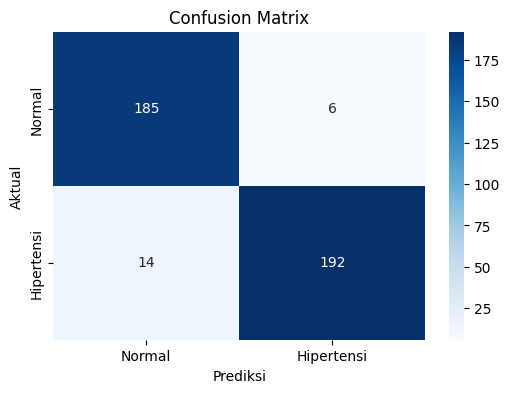

In [14]:
# Evaluasi Model Terbaik
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Hasil Evaluasi Model Terbaik")
print(f"Kombinasi Parameter Terbaik: {grid_search.best_params_}")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Menampilkan visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Hipertensi'], yticklabels=['Normal', 'Hipertensi'])
plt.title('Confusion Matrix')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

In [15]:
# Ekspor Model Final
joblib.dump(best_model, 'best_rf_model.pkl')
print("\nModel terbaik berhasil disimpan sebagai 'best_rf_model.pkl'")


Model terbaik berhasil disimpan sebagai 'best_rf_model.pkl'
